# Test of the Reciever Simulator


In [123]:
from simulation.observation_handler import ObservationHandler
from simulation.loads import Load
from simulation.receiver import Receiver

import matplotlib.pyplot as plt
import numpy as np
import astropy.units as un

import os

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams.update({
    "font.family": "serif"
})

In [124]:
test_receiver = Receiver(gamma_rec_s2p_path='/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/RecBlockSDR0.s2p',
                         gains_s2p_path='/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/RecBlock0.s2p')

test_receiver.change_freqs(np.linspace(60*un.MHz, 80*un.MHz, 1024))

open_load = Load(physical_temperature=273,
                 label='open',
                 termination_type='open',
                 freqs=test_receiver.freqs)

short_load = Load(physical_temperature=273,
                 label='short',
                 termination_type='short',
                 freqs=test_receiver.freqs)

long_open = Load(physical_temperature=273,
                 label='long_open',
                 termination_type='open',
                 effective_cable_length=3*un.m,
                 freqs=test_receiver.freqs)

long_short = Load(physical_temperature=273,
                 label='long_short',
                 termination_type='short',
                 effective_cable_length=3*un.m,
                 freqs=test_receiver.freqs)

matched_ambient = Load(physical_temperature=273,
                       label='internal_load',
                       termination_type='matched',
                       freqs=test_receiver.freqs)

heated_load = Load(physical_temperature=matched_ambient.t_src+40,
                      label='heated_load',
                      termination_type='matched',
                      freqs=test_receiver.freqs)


test_src = Load(physical_temperature=350,
                termination_impedence=75*un.Ohm,
                freqs=test_receiver.freqs,
                effective_cable_length=5*un.m,
                label='Test_src')


observation_handler_obj = ObservationHandler(observation_length=6*3600*un.s,
                                             receiver=test_receiver,
                                             sources=[long_open,
                                                      long_short,
                                                      open_load,
                                                      short_load,
                                                      test_src,
                                                      test_src,
                                                      test_src,
                                                      test_src],
                                            dicke_switch_sources=[matched_ambient,
                                                                  heated_load],
                                            dicke_switch_length=300*un.s,
                                            delta_t=10*un.s,
                                            n_t_unc_freq_coeffs=5,
                                            n_t_unc_time_coeffs=2,
                                            n_t_sin_freq_coeffs=3,
                                            n_t_sin_time_coeffs=3,
                                            n_t_cos_freq_coeffs=4,
                                            n_t_cos_time_coeffs=4)



Done


In [125]:
os.makedirs('simulated_data',
          exist_ok=True)

observation_handler_obj.save_to_hdf5(filepath="simulated_data/sim_data.hdf5")


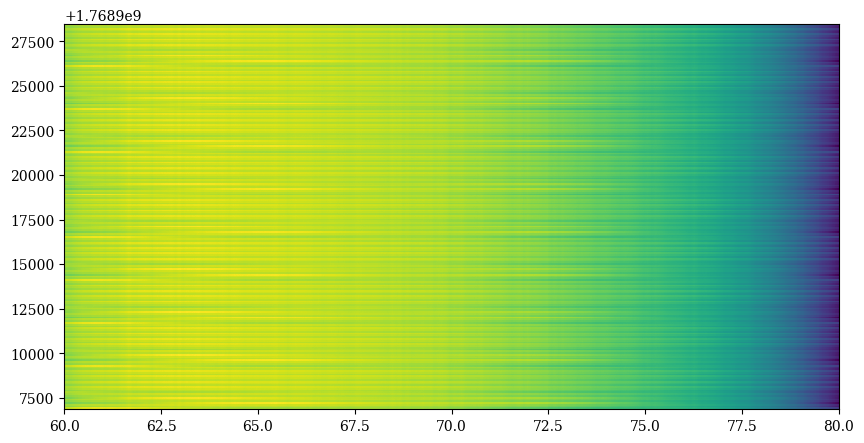

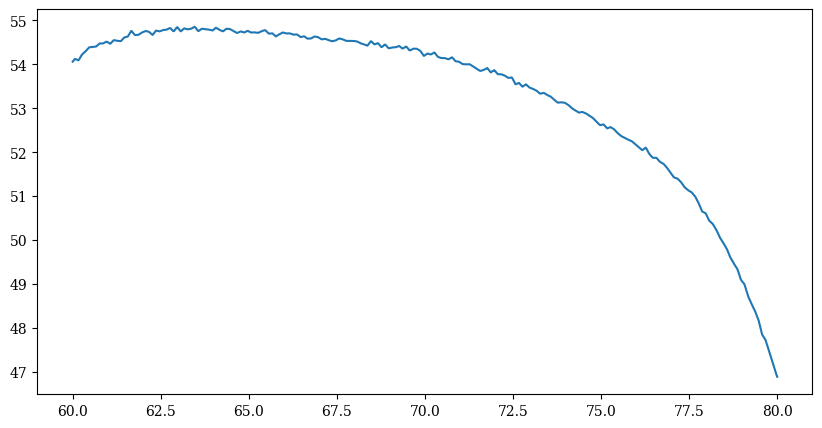

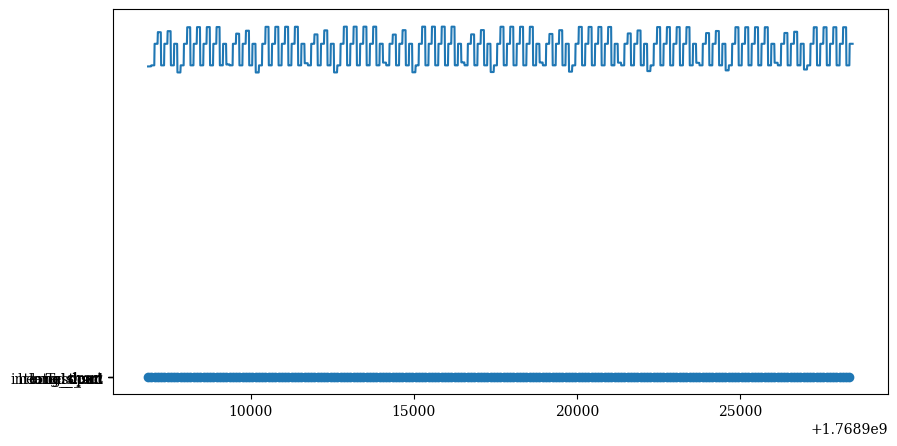

<class 'str'>
<class 'numpy.float64'>
internal_load
[273.0517574  273.05600335 272.98750384 ... 273.02588307 273.18591908
 273.00085573]
----
heated_load
[313.06719548 313.07234564 313.22314686 ... 313.01858364 313.19320677
 313.01563912]
----
long_open
[272.94290565 273.00982497 273.04026502 ... 272.99269701 273.1112065
 272.93509031]
----
long_short
[273.09167437 273.0677729  272.80644292 ... 272.90388936 272.92621083
 273.04230248]
----
open
[272.9618123  273.00832042 272.95502524 ... 273.01060617 272.84054645
 272.9697939 ]
----
short
[273.08039942 273.01292864 273.09260408 ... 272.97071555 273.09623534
 273.08435025]
----
Test_src
[349.964818   349.95939743 349.89267328 ... 350.12122945 349.99614957
 350.02279183]
----


In [126]:

plt.pcolormesh(np.array(observation_handler_obj.freqs),
               np.array(observation_handler_obj.times),
               10*np.log10(observation_handler_obj.data))
plt.show()

plt.plot(observation_handler_obj.freqs,10*np.log10(np.mean(observation_handler_obj.data, axis=0)))
plt.show()

plt.plot(observation_handler_obj.times, observation_handler_obj.data.sum(axis=1))
plt.scatter(observation_handler_obj.switch_times, observation_handler_obj.switch_states)
plt.show()

print(type(observation_handler_obj.switch_states[0]))
print(type(observation_handler_obj.switch_times[0]))


for i, k in observation_handler_obj.temperature_dict.items():
    print(i)
    print(k)
    print('----')


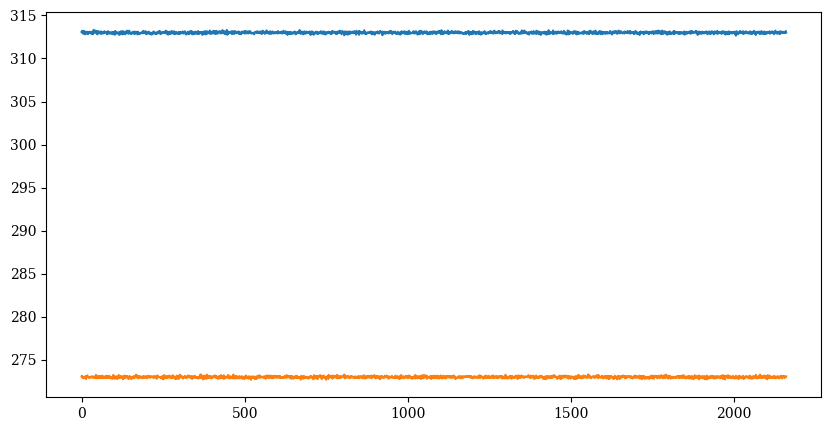

In [127]:
plt.plot(observation_handler_obj.temperature_dict['heated_load'])
plt.plot(observation_handler_obj.temperature_dict['short'])

In [128]:
from gcr.data_processing import create_nw_data_and_covariance_from_raw
from gcr.transfer_matrix_construction import construct_transfer_matrix


data_waterfall, covar_waterfall, final_times, final_states = create_nw_data_and_covariance_from_raw(waterfall=observation_handler_obj.data,
                                                                             times=observation_handler_obj.times,
                                                                             freqs=observation_handler_obj.freqs,
                                                                             switch_times=observation_handler_obj.switch_times,
                                                                             switch_states=observation_handler_obj.switch_states,
                                                                             source_temperatures=observation_handler_obj.temperature_dict,
                                                                             gamma_src_dict=observation_handler_obj.gamma_src_dict,
                                                                             noise_wave_loads=['open',
                                                                                               'short',
                                                                                               'long_open',
                                                                                               'long_short'],
                                                                            internal_load_label='internal_load',
                                                                            noise_source_label='heated_load',
                                                                            switch_buffer=2*un.s,
                                                                            gamma_rec=observation_handler_obj.gamma_rec)


True
True
True
True
False
False
False
False
True
True
True
True
False
False
False
False
True
True
True
True
False
False
False
False
True
True
True
True
False
False
False
False
True
True
True
True
False
False
False
False
True
True
True
True
False
False
False
False
True
True
True
True
False
False
False
False
True
True
True
True
False
False
False
False
True
True
True
True
False
False
False
False


In [129]:
print(final_states)

[np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short')]


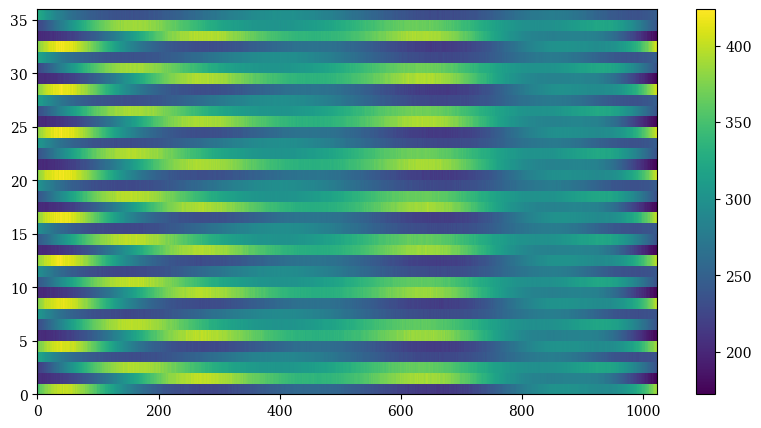

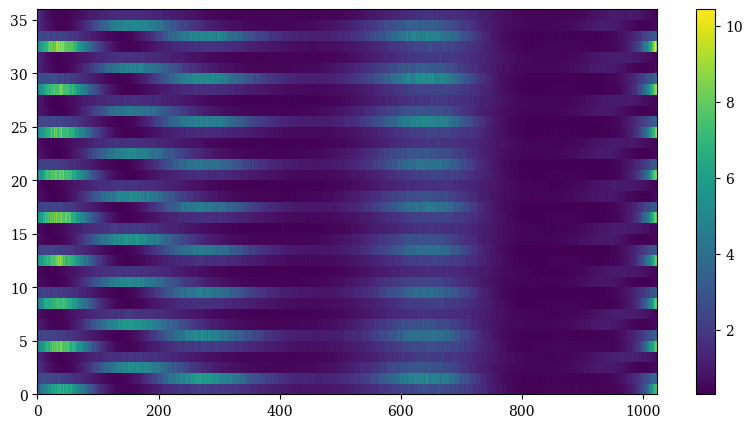

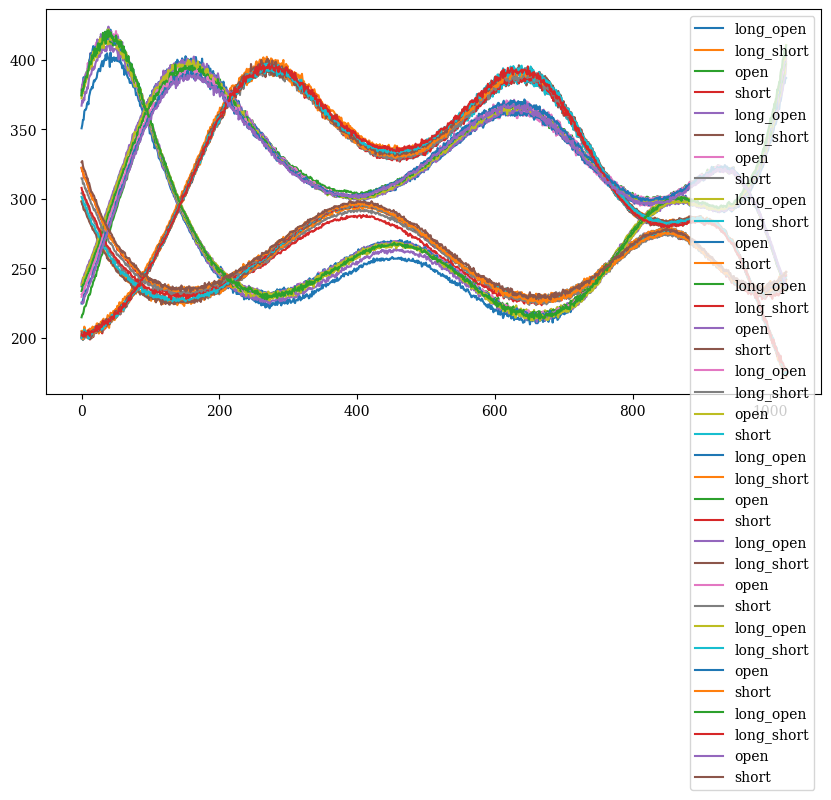

In [130]:
plt.pcolormesh(data_waterfall)
plt.colorbar()
plt.show()

plt.pcolormesh(covar_waterfall)
plt.colorbar()
plt.show()

for l, state in zip(data_waterfall, final_states):
    plt.plot(l, label=state)
plt.legend()
plt.show()



In [131]:
print(type(final_times[0]))

example_time = 100 *un.day

float_time = float(example_time.to(un.s) / un.s)

print(float_time)

<class 'float'>
8640000.0


In [132]:
unc_coeffs_deg = (5,5)
cos_coeffs_deg = (5,5)
sin_coeffs_deg = (5,5)

transfer_matrix, (freq_norm, time_norm) = construct_transfer_matrix(np.array(observation_handler_obj.freqs),
                                            np.array(final_times),
                                            switch_states_array=final_states,
                                            unc_poly_orders=unc_coeffs_deg,
                                            cos_poly_orders=cos_coeffs_deg,
                                            sin_poly_orders=sin_coeffs_deg,
                                            switch_state_src_gamma_dict=observation_handler_obj.gamma_src_dict,
                                            gamma_rec=observation_handler_obj.gamma_rec,
                                            return_norm_funcs=True)

print(freq_norm)


<function array_normalisation.<locals>.array_norm_func at 0x15ea09120>


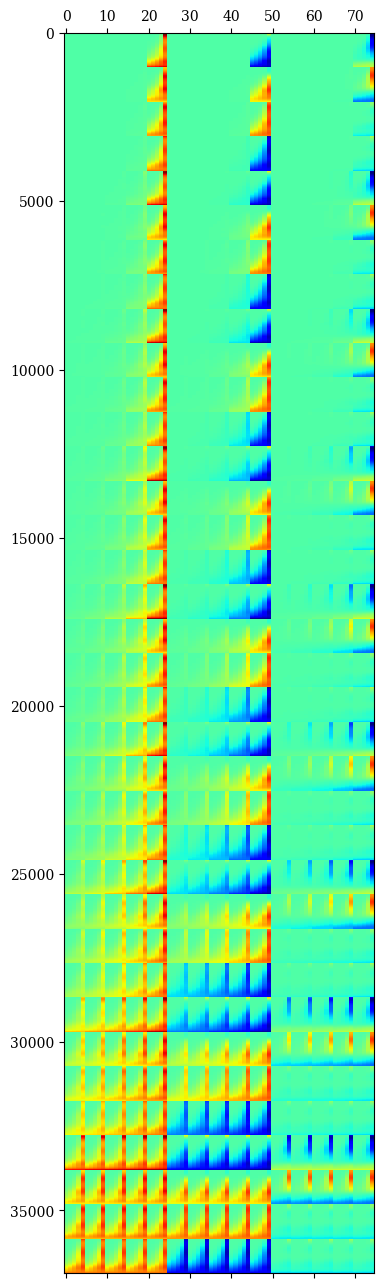

In [133]:
plt.matshow(transfer_matrix, aspect='auto', cmap='jet')
plt.show()

(36864,)
(36864, 75)
[ 1.15052920e+01 -7.76775177e+01  8.43563874e+01 -2.55578314e+01
  1.90146309e+00  1.16313274e+02 -1.01271429e+02 -1.59766419e+01
  1.76730298e+01 -2.25296638e+00 -1.76409705e+02  2.50748515e+02
 -9.73555138e+01  1.06630693e+01  6.56918895e-01  4.99878439e+02
 -9.56346585e+02  5.81211817e+02 -1.19404063e+02  7.30920142e+00
 -6.35652762e+02  1.35468533e+03 -9.43267609e+02  2.32131353e+02
  2.86167718e+02 -2.87082837e+02  6.49546031e+02 -4.71640995e+02
  1.19323256e+02 -5.56738660e+00  6.79094224e+02 -1.62888380e+03
  1.86469642e+03 -1.10701319e+03  1.88623795e+02 -5.08743654e+02
  2.00600302e+03 -3.26832176e+03  2.16277471e+03 -3.81196407e+02
  1.20574387e+02 -1.17373608e+03  2.12329269e+03 -1.29539616e+03
  2.08574429e+02 -4.56020682e+00  4.00720880e+01 -8.04326296e+01
  6.69303386e+01  1.05996632e+01 -3.14176662e+02  3.07308643e+02
  7.74474220e+01 -8.24641876e+01  8.04971590e+00  9.85217696e+02
 -1.25584929e+03  1.92972098e+02  1.02264385e+02 -1.33889422e+01
 -9.

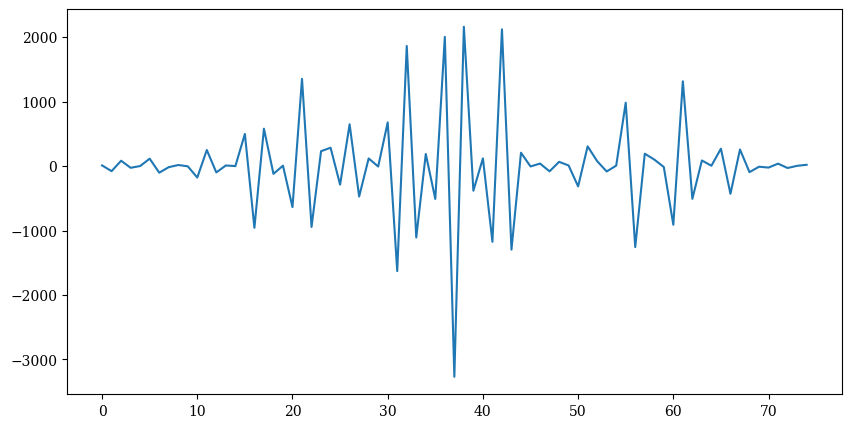

In [134]:
flattened_data = data_waterfall.flatten()

print(flattened_data.shape)
print(transfer_matrix.shape)

t_vec = np.linalg.lstsq(transfer_matrix, flattened_data)[0]


plt.plot(t_vec)


print(t_vec)

In [135]:
from gcr.basis_construction import reconstruct_surface

In [136]:
n_t_unc_coeffs = unc_coeffs_deg[0]*unc_coeffs_deg[-1]
n_t_cos_coeffs = cos_coeffs_deg[0]*cos_coeffs_deg[-1]
n_t_sin_coeffs = sin_coeffs_deg[0]*sin_coeffs_deg[-1]


t_unc_coeffs = t_vec[:n_t_unc_coeffs]
t_cos_coeffs = t_vec[n_t_unc_coeffs:n_t_unc_coeffs+n_t_cos_coeffs]
t_sin_coeffs = t_vec[n_t_unc_coeffs+n_t_cos_coeffs:]

print(t_unc_coeffs)
print(t_cos_coeffs)
print(t_sin_coeffs)

[ 1.15052920e+01 -7.76775177e+01  8.43563874e+01 -2.55578314e+01
  1.90146309e+00  1.16313274e+02 -1.01271429e+02 -1.59766419e+01
  1.76730298e+01 -2.25296638e+00 -1.76409705e+02  2.50748515e+02
 -9.73555138e+01  1.06630693e+01  6.56918895e-01  4.99878439e+02
 -9.56346585e+02  5.81211817e+02 -1.19404063e+02  7.30920142e+00
 -6.35652762e+02  1.35468533e+03 -9.43267609e+02  2.32131353e+02
  2.86167718e+02]
[ -287.08283724   649.5460311   -471.64099503   119.32325647
    -5.5673866    679.09422443 -1628.8837974   1864.69642454
 -1107.01319294   188.6237954   -508.74365439  2006.00301888
 -3268.32176009  2162.77470515  -381.19640742   120.57438698
 -1173.73607553  2123.29269018 -1295.3961623    208.57442854
    -4.56020682    40.072088     -80.43262963    66.93033859
    10.59966323]
[ -314.17666151   307.30864252    77.44742205   -82.4641876
     8.0497159    985.21769625 -1255.84929487   192.97209827
   102.26438517   -13.38894221  -909.49815953  1316.62996388
  -506.59386869    88.26966

In [137]:

t_unc_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_unc_coeffs,
                                    n_x_coeffs=unc_coeffs_deg[0],
                                    n_y_coeffs=unc_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_cos_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_cos_coeffs,
                                    n_x_coeffs=cos_coeffs_deg[0],
                                    n_y_coeffs=cos_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_sin_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_sin_coeffs,
                                    n_x_coeffs=sin_coeffs_deg[0],
                                    n_y_coeffs=sin_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)


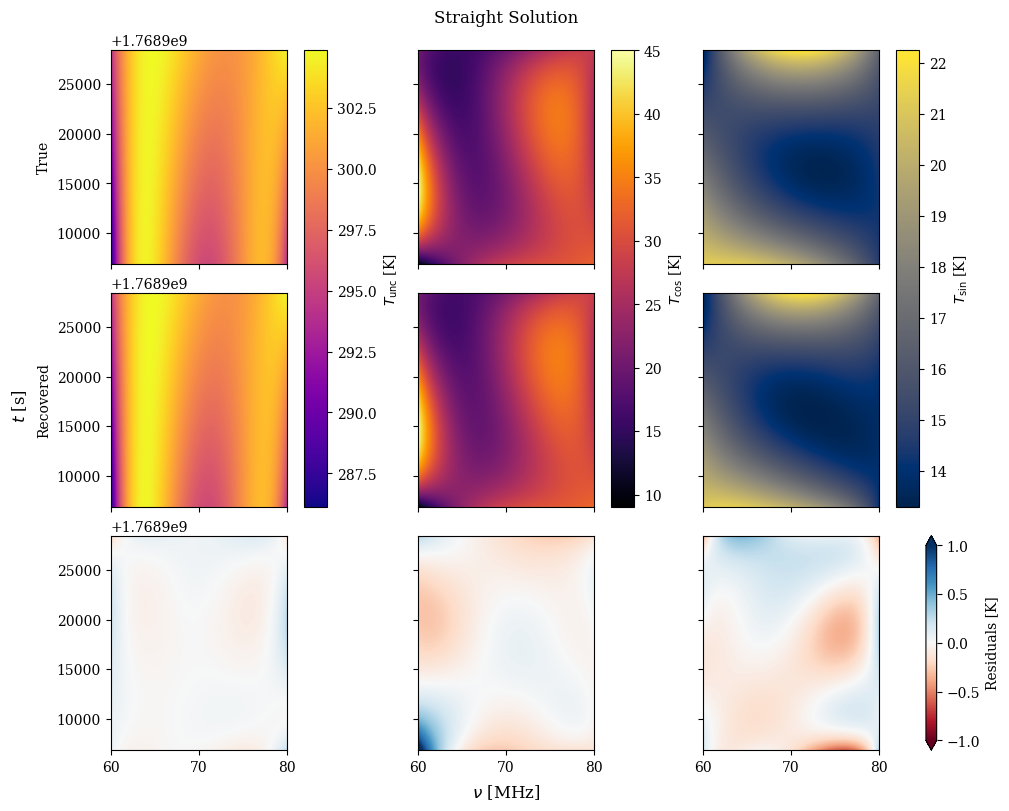

In [138]:
# Plot Residuals and Reconstructed Surface
fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         sharex=True,
                         layout='constrained',
                         figsize=(10,8),
                         sharey=True)

resid_vminmax = 1

unc = axes[0,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc,
                     cmap='plasma')

unc = axes[1,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_unc_surface,
                     cmap='plasma')

res = axes[2,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc - t_unc_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

cos = axes[0,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos,
                     cmap='inferno')

cos = axes[1,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_cos_surface,
                     cmap='inferno')

res = axes[2,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos - t_cos_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

sin = axes[0,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin,
                     cmap='cividis')

sin  = axes[1,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_sin_surface,
                     cmap='cividis')

res = axes[2,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin - t_sin_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')


axes[0,0].set_ylabel('True')
axes[1,0].set_ylabel('Recovered')


fig.colorbar(res,
             ax=[axes[2,i] for i in range(3)],
             label='Residuals [K]',
             extend='both')

fig.colorbar(unc,
             ax=[axes[i,0] for i in range(2)],
             label=r'$T_{\rm unc}$ [K]')

fig.colorbar(cos,
             ax=[axes[i,1] for i in range(2)],
             label=r'$T_{\rm cos}$ [K]')

fig.colorbar(sin,
             ax=[axes[i,2] for i in range(2)],
             label=r'$T_{\rm sin}$ [K]')

fig.supxlabel(r'$\nu$ [MHz]')
fig.supylabel(r'$t$ [s]')
fig.suptitle('Straight Solution')
plt.show()


In [139]:
flat_cov = covar_waterfall.flatten()
inv_cov = 1 / flat_cov

from gcr.noise_wave_gcr import construct_gcr_lhs, construct_gcr_rhs
from scipy.sparse.linalg import cg


S_cov = np.abs(t_vec) / 2
S_inv = np.zeros_like(t_vec)# 1/S_cov
S_inv = 1/S_cov #  np.zeros_like(t_vec)# 1/S_cov

lhs = construct_gcr_lhs(transfer_matrix,
                        N_inv_1d=inv_cov,
                        S_inv=S_inv)

rhs = construct_gcr_rhs(d=flattened_data,
                        H_matrix=transfer_matrix,
                        N_inv_1d=inv_cov,
                        S_inv=S_inv,
                        T_nw0=t_vec,
                        omega_d=np.random.normal(loc=0, scale=1, size=flattened_data.shape),
                        omega_t=np.random.normal(loc=0, scale=1, size=t_vec.shape))

gcr_wsol = cg(lhs, rhs, x0=t_vec)[0]


In [140]:
t_unc_coeffs = gcr_wsol[:n_t_unc_coeffs]
t_cos_coeffs = gcr_wsol[n_t_unc_coeffs:n_t_unc_coeffs+n_t_cos_coeffs]
t_sin_coeffs = gcr_wsol[n_t_unc_coeffs+n_t_cos_coeffs:]

print(t_unc_coeffs)
print(t_cos_coeffs)
print(t_sin_coeffs)


t_unc_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_unc_coeffs,
                                    n_x_coeffs=unc_coeffs_deg[0],
                                    n_y_coeffs=unc_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_cos_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_cos_coeffs,
                                    n_x_coeffs=cos_coeffs_deg[0],
                                    n_y_coeffs=cos_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_sin_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_sin_coeffs,
                                    n_x_coeffs=sin_coeffs_deg[0],
                                    n_y_coeffs=sin_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)


[ 1.15031110e+01 -7.76831667e+01  8.43519466e+01 -2.55687897e+01
  1.88273796e+00  1.16312485e+02 -1.01275157e+02 -1.59815230e+01
  1.76683054e+01 -2.26756992e+00 -1.76411715e+02  2.50749940e+02
 -9.73569941e+01  1.06630610e+01  6.54983985e-01  4.99879578e+02
 -9.56347042e+02  5.81215683e+02 -1.19400775e+02  7.32565486e+00
 -6.35662707e+02  1.35467839e+03 -9.43277141e+02  2.32122033e+02
  2.86162495e+02]
[ -287.08462814   649.5463947   -471.64337609   119.32669905
    -5.55684734   679.09499586 -1628.88743385  1864.69472701
 -1107.01634821   188.63079111  -508.74583315  2006.00111274
 -3268.32888958  2162.76954683  -381.20155392   120.57617513
 -1173.74073845  2123.28688043 -1295.40804621   208.56482155
    -4.55793987    40.07286028   -80.43960236    66.92167885
    10.5826298 ]
[ -314.19480388   307.29272082    77.43119123   -82.48143512
     8.0536633    985.20041492 -1255.87013089   192.95350402
   102.24784866   -13.38469926  -909.52162397  1316.60836911
  -506.61915152    88.2489

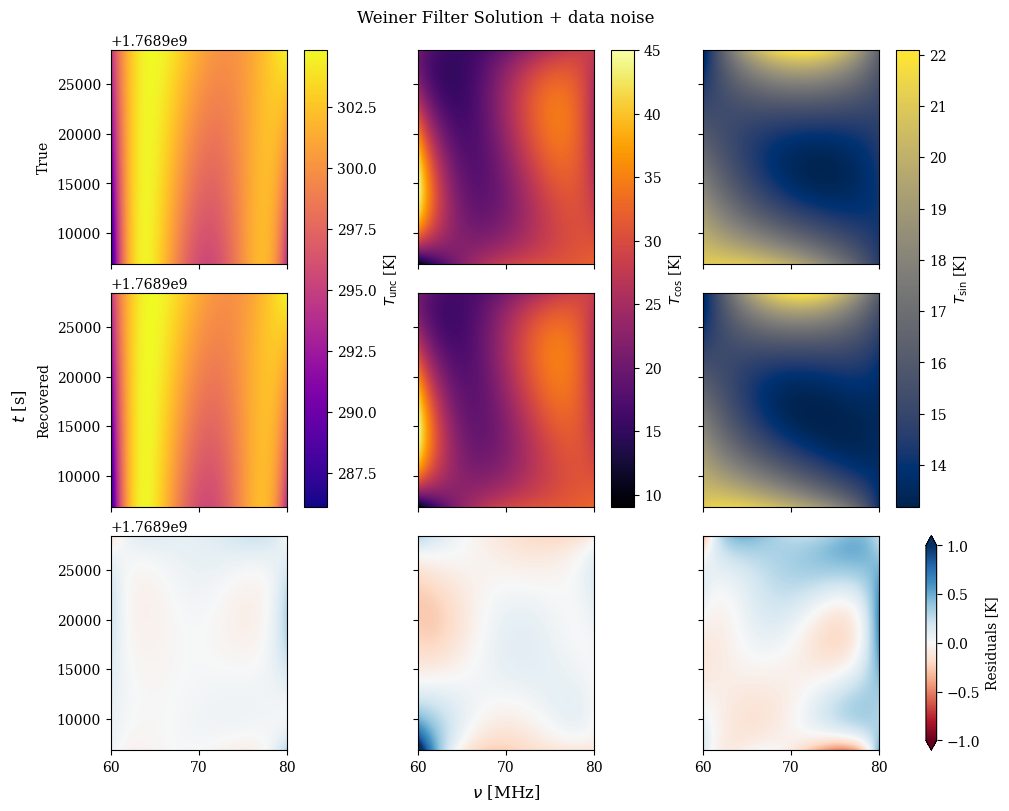

In [141]:

# Plot Residuals and Reconstructed Surface
fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         sharex=True,
                         layout='constrained',
                         figsize=(10,8),
                         sharey=True)


unc = axes[0,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc,
                     cmap='plasma')

unc = axes[1,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_unc_surface,
                     cmap='plasma')

res = axes[2,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc - t_unc_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

cos = axes[0,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos,
                     cmap='inferno')

cos = axes[1,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_cos_surface,
                     cmap='inferno')

res = axes[2,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos - t_cos_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

sin = axes[0,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin,
                     cmap='cividis')

sin  = axes[1,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_sin_surface,
                     cmap='cividis')

res = axes[2,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin - t_sin_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')


axes[0,0].set_ylabel('True')
axes[1,0].set_ylabel('Recovered')


fig.colorbar(res,
             ax=[axes[2,i] for i in range(3)],
             label='Residuals [K]',
             extend='both')

fig.colorbar(unc,
             ax=[axes[i,0] for i in range(2)],
             label=r'$T_{\rm unc}$ [K]')

fig.colorbar(cos,
             ax=[axes[i,1] for i in range(2)],
             label=r'$T_{\rm cos}$ [K]')

fig.colorbar(sin,
             ax=[axes[i,2] for i in range(2)],
             label=r'$T_{\rm sin}$ [K]')

fig.supxlabel(r'$\nu$ [MHz]')
fig.supylabel(r'$t$ [s]')
fig.suptitle('Weiner Filter Solution + data noise')
plt.show()


In [142]:
t_vec - gcr_wsol

array([ 2.18093796e-03,  5.64903419e-03,  4.44075836e-03,  1.09583031e-02,
        1.87251295e-02,  7.88335394e-04,  3.72772877e-03,  4.88110079e-03,
        4.72440977e-03,  1.46035389e-02,  2.00943744e-03, -1.42532500e-03,
        1.48021826e-03,  8.25172746e-06,  1.93491027e-03, -1.13874057e-03,
        4.57025506e-04, -3.86609299e-03, -3.28793388e-03, -1.64534449e-02,
        9.94507326e-03,  6.93583810e-03,  9.53144648e-03,  9.32023591e-03,
        5.22281077e-03,  1.79090240e-03, -3.63599184e-04,  2.38106243e-03,
       -3.44258488e-03, -1.05392648e-02, -7.71436927e-04,  3.63645259e-03,
        1.69753068e-03,  3.15526756e-03, -6.99571293e-03,  2.17875687e-03,
        1.90613554e-03,  7.12948997e-03,  5.15831583e-03,  5.14649108e-03,
       -1.78814343e-03,  4.66291785e-03,  5.80974489e-03,  1.18839039e-02,
        9.60699190e-03, -2.26694961e-03, -7.72273011e-04,  6.97272680e-03,
        8.65974256e-03,  1.70334315e-02,  1.81423704e-02,  1.59217075e-02,
        1.62308151e-02,  